In [4]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

#Evaluation library
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# Deep Learning libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential

#from keras.layers.core import Dense,Activation,Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from keras.datasets import mnist
#from keras.utils.np_utils import to_categorical
from keras.utils import to_categorical
#from keras.wrappers.scikit_learn import KerasClassifier
from scikeras.wrappers import KerasClassifier

In [2]:
#!pip install tensorflow==2.7.0

In [5]:
#Digit MNIST dataset
(X_train_digit, y_train_digit), (X_test_digit, y_test_digit) = mnist.load_data()

In [6]:
X_train_digit[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [7]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

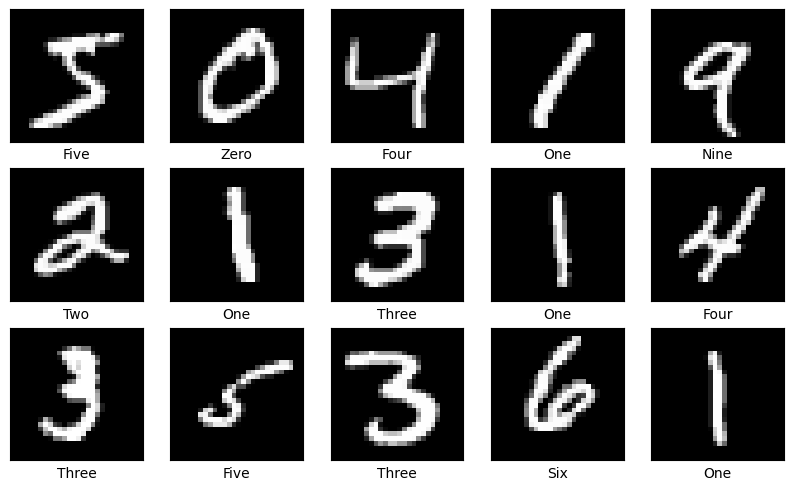

In [6]:
#Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#Visualizing the digits
plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_digit[i], cmap='gray')
    plt.xlabel(col_names[y_train_digit[i]])
plt.show()

In [7]:
X_train_digit.shape

(60000, 28, 28)

In [8]:
X_train_digit = X_train_digit.reshape(60000, 784)
X_test_digit = X_test_digit.reshape(10000, 784)

In [9]:
X_train_digit.shape

(60000, 784)

In [10]:
y_test_digit.shape

(10000,)

In [11]:
#Encoding Digit MNIST Labels
y_train_digit = to_categorical(y_train_digit, num_classes=10)

y_test_digit = to_categorical(y_test_digit, num_classes=10)

In [46]:
y_train_digit[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [47]:
#Creating base neural network
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    #layers.Dropout(0.3),
    #layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    #layers.Dropout(0.3),
    #layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    #layers.Dropout(0.3),
    #layers.BatchNormalization(),
    #layers.Dense(10,activation='sigmoid'),
    layers.Dense(10, activation='softmax')
])

In [14]:
#param_number = output_channel_number * (input_channel_number + 1)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,218 (868.04 KB)

 Trainable params: 222,218 (868.04 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#Compiling the model
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics = ['accuracy'])


In [17]:
history=model.fit(X_train_digit, y_train_digit, batch_size=100, epochs=10,validation_data=(X_test_digit, y_test_digit))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7498 - loss: 1.3780 - val_accuracy: 0.8520 - val_loss: 0.3449
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8597 - loss: 0.2489 - val_accuracy: 0.8693 - val_loss: 0.2474
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8741 - loss: 0.1691 - val_accuracy: 0.8493 - val_loss: 0.2295
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8651 - loss: 0.1313 - val_accuracy: 0.8570 - val_loss: 0.1764
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8629 - loss: 0.1128 - val_accuracy: 0.8478 - val_loss: 0.1612
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8571 - loss: 0.1065 - val_accuracy: 0.8526 - val_loss: 0.1662
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8323 - loss: 0.0946 - val_accuracy: 0.7954 - val_loss: 0.1791
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8465 - loss: 0.0791 - val_accuracy: 0.

In [18]:
#Predicting the labels-DIGIT
y_predict = model.predict(X_test_digit)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [19]:
y_predict[0]

array([3.8398340e-04, 9.6061325e-01, 9.8809278e-01, 9.8368490e-01,
       1.6415794e-01, 6.4295733e-08, 3.2958787e-15, 1.0000000e+00,
       4.9898180e-04, 9.9951148e-01], dtype=float32)

In [20]:
y_predicts=np.argmax(y_predict, axis=1) # Here we get the index of maximum value in the encoded vector


In [21]:
y_predicts

array([7, 1, 1, ..., 4, 5, 6], shape=(10000,))

In [22]:
y_test_digit_eval=np.argmax(y_test_digit, axis=1)

In [23]:
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

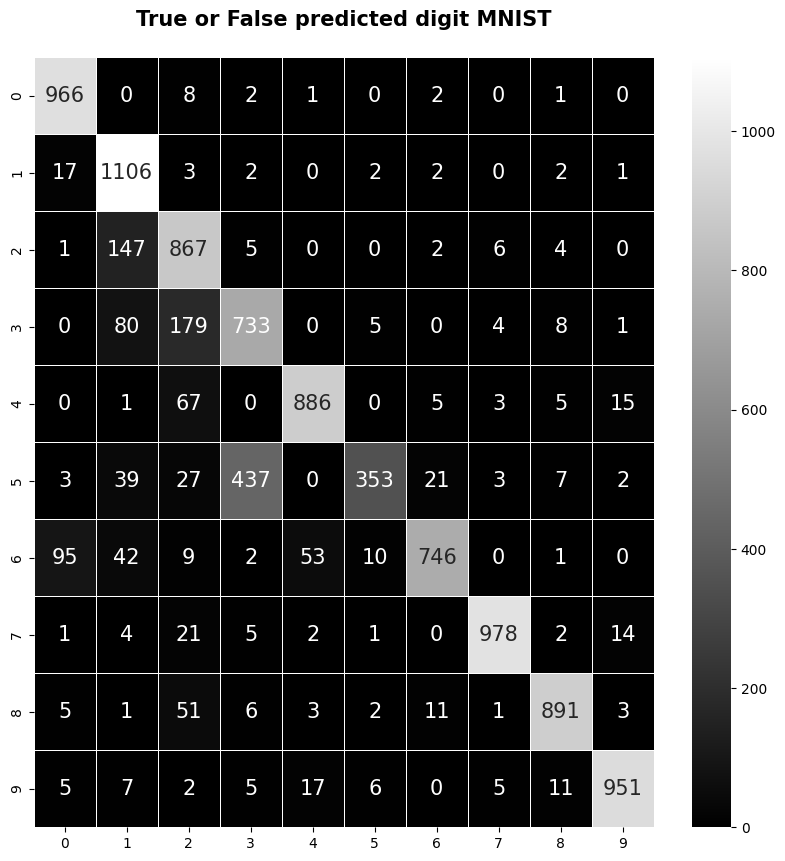

In [25]:
#Confusion matrix for Digit MNIST
con_mat=confusion_matrix(y_test_digit_eval,y_predicts)
#plt.style.use('seaborn-deep')
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size': 15},linewidths=0.5,fmt="d",cmap="gray")
plt.title('True or False predicted digit MNIST\n',fontweight='bold',fontsize=15)
plt.show()

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test_digit_eval,y_predicts))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       980
           1       0.78      0.97      0.86      1135
           2       0.70      0.84      0.77      1032
           3       0.61      0.73      0.66      1010
           4       0.92      0.90      0.91       982
           5       0.93      0.40      0.56       892
           6       0.95      0.78      0.85       958
           7       0.98      0.95      0.96      1028
           8       0.96      0.91      0.93       974
           9       0.96      0.94      0.95      1009

    accuracy                           0.85     10000
   macro avg       0.87      0.84      0.84     10000
weighted avg       0.86      0.85      0.84     10000



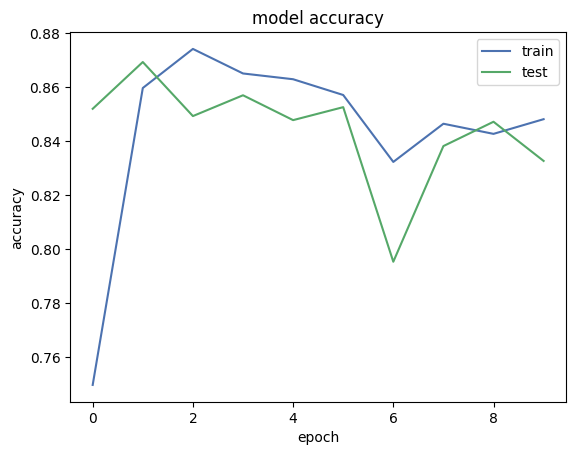

In [27]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()


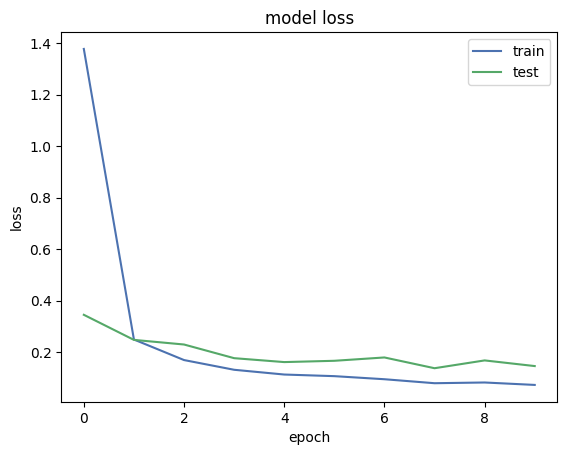

In [28]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

In [52]:
#tf.expand_dims(X_test_digit[0])
y_predict_single = model.predict(X_test_digit[[2]])
y_predicts_single=np.argmax(y_predict_single, axis=1) # Here we get the index of maximum value in the encoded vector
#y_test_digit_eval=np.argmax(y_test_digit, axis=1)
y_test_digit_eval = np.argmax(y_test_digit, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


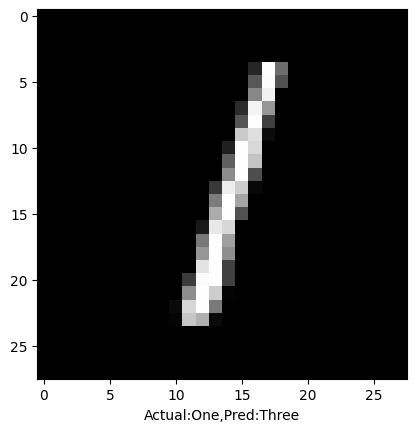

In [53]:
#Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#Visualizing the digits
#plt.figure(figsize=(10,10))
plt.imshow(X_test_digit[2].reshape(28,28), cmap='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[np.argmax(y_test_digit[2])],col_names[y_predicts_single[0]]))
plt.show()

# # Names of numbers
# col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

# # Show image
# plt.imshow(X_test_digit[2].reshape(28,28), cmap='gray')

# # Labels
# plt.xlabel(
#     "Actual: {}, Pred: {}".format(
#         col_names[y_test_digit[2]], 
#         col_names[y_predicts_single[0]]
#     )
# )

# plt.axis('off')
# plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


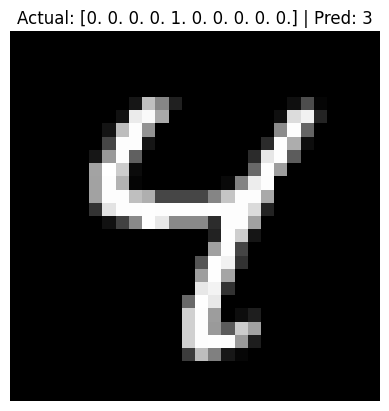

[[8.1099257e-05 6.5138943e-06 6.5550362e-06 9.9990571e-01 1.7454108e-28
  2.6492488e-20 1.8221028e-24 1.5548247e-20 2.4445303e-08 1.7948096e-19]]


In [62]:
idx = 6  # try any number from 0 to 9999

y_pred = model.predict(X_test_digit[[idx]])
y_pred_class = np.argmax(y_pred, axis=1)[0]

plt.imshow(X_test_digit[idx].reshape(28,28), cmap='gray')
plt.title(f"Actual: {y_test_digit[idx]} | Pred: {y_pred_class}")
plt.axis('off')
plt.show()

print(y_pred)

In [58]:
y_pred_all = model.predict(X_test_digit)
y_pred_classes = np.argmax(y_pred_all, axis=1)

wrong = np.where(y_pred_classes != y_test_digit_eval)[0]


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


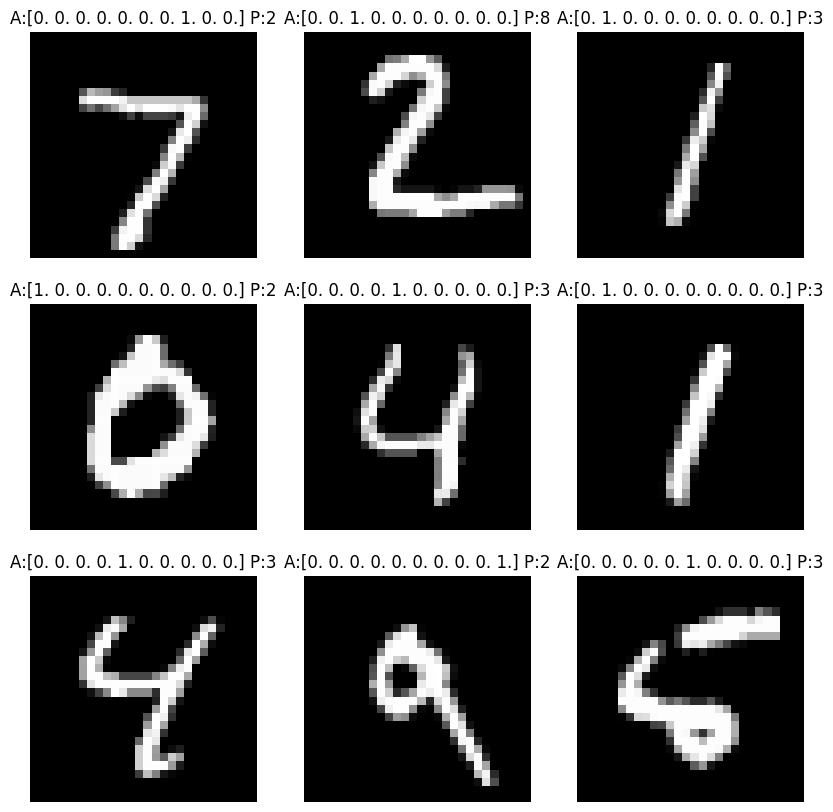

In [59]:
plt.figure(figsize=(10,10))

for i, idx in enumerate(wrong[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test_digit[idx].reshape(28,28), cmap='gray')
    plt.title(f"A:{y_test_digit[idx]} P:{y_pred_classes[idx]}")
    plt.axis('off')

plt.show()

In [61]:
print(y_test_digit.shape)        # (10000, 10)
print(y_test_digit_eval.shape)   # (10000,)
print(y_pred_classes.shape)     # (10000,)

(10000, 10)
(10000,)
(10000,)


In [21]:

(X_train_digit, y_train_digit), (X_test_digit, y_test_digit) = mnist.load_data()

print(X_train_digit.shape)  # (60000, 28, 28)
print(X_test_digit.shape)   # (10000, 28, 28)

(60000, 28, 28)
(10000, 28, 28)


In [22]:
# Normalize
X_train_digit = X_train_digit / 255.0
X_test_digit = X_test_digit / 255.0

# Flatten images
X_train_digit = X_train_digit.reshape(-1, 784)
X_test_digit = X_test_digit.reshape(-1, 784)

In [23]:
new_model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

c:\Anaconda\anaconda3\envs\v_env2\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
new_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

In [30]:
history = new_model.fit(
    X_train_digit,
    y_train_digit,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9939 - loss: 0.0198 - val_accuracy: 0.9790 - val_loss: 0.1083
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9945 - loss: 0.0168 - val_accuracy: 0.9758 - val_loss: 0.1166
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9948 - loss: 0.0169 - val_accuracy: 0.9810 - val_loss: 0.0945
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9958 - loss: 0.0136 - val_accuracy: 0.9808 - val_loss: 0.0981
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9944 - loss: 0.0177 - val_accuracy: 0.9832 - val_loss: 0.0753
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9962 - loss: 0.0130 - val_accuracy: 0.9825 - val_loss: 0.0952
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9967 - loss: 0.0103 - val_accuracy: 0.9790 - val_loss: 0.1061
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9960 - loss: 0.0130 -

In [31]:
test_loss, test_acc = new_model.evaluate(X_test_digit, y_test_digit)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9787 - loss: 0.1096
Test Accuracy: 0.9786999821662903


In [32]:
new_model.fit(X_train_digit, y_train_digit, epochs=10, batch_size=32)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9944 - loss: 0.0222
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9964 - loss: 0.0125
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9964 - loss: 0.0117
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9960 - loss: 0.0128
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9968 - loss: 0.0103
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9969 - loss: 0.0099
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9973 - loss: 0.0089
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9970 - loss: 0.0098
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9977 - loss: 0.0080
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9976 - loss: 0.0092


In [33]:
y_pred_all = model.predict(X_test_digit)

y_pred_classes = np.argmax(y_pred_all, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [35]:
wrong = np.where(y_pred_classes != y_test_digit)[0]

print("Number of wrong predictions:", len(wrong))

Number of wrong predictions: 9165


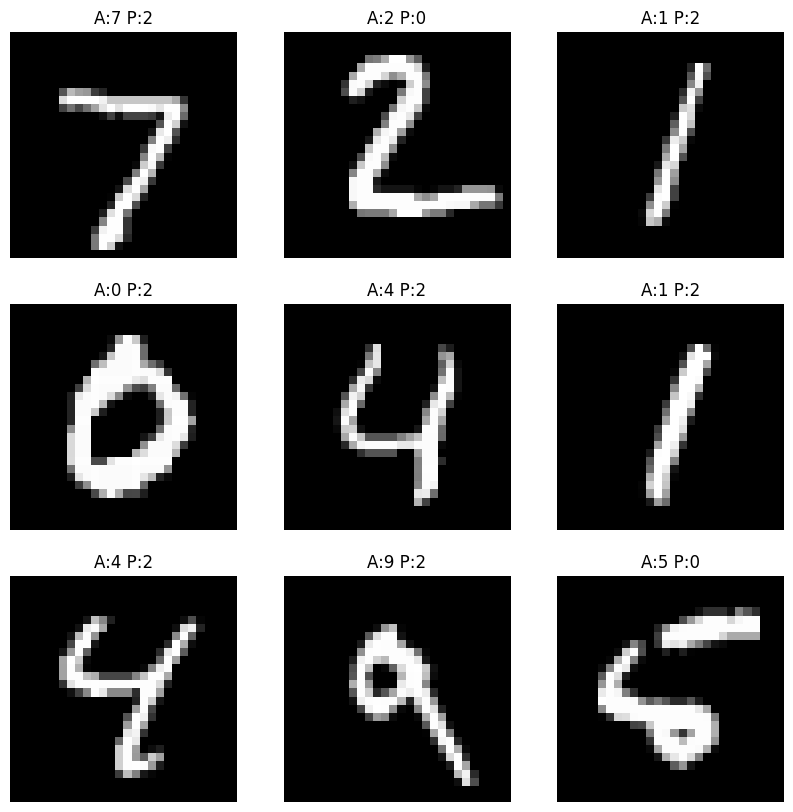

In [37]:
plt.figure(figsize=(10,10))

for i, idx in enumerate(wrong[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test_digit[idx].reshape(28,28), cmap='gray')
    plt.title(f"A:{y_test_digit[idx]} P:{y_pred_classes[idx]}")
    plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


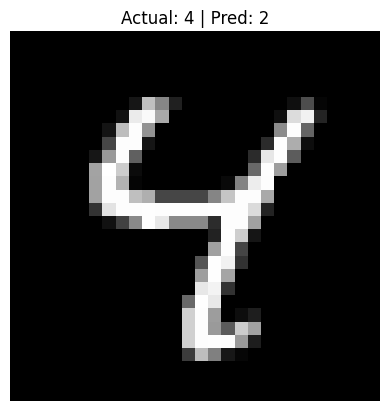

Probabilities: [[0.09355885 0.11062866 0.11753402 0.10999704 0.09289201 0.08680089
  0.10915229 0.09899918 0.08023755 0.10019956]]


In [38]:
idx = 6

y_pred = model.predict(X_test_digit[[idx]])
y_pred_class = np.argmax(y_pred, axis=1)[0]

plt.imshow(X_test_digit[idx].reshape(28,28), cmap='gray')
plt.title(f"Actual: {y_test_digit[idx]} | Pred: {y_pred_class}")
plt.axis('off')
plt.show()

print("Probabilities:", y_pred)

In [40]:
print("Test Accuracy:", test_acc)

Test Accuracy: 0.9786999821662903
